# Exploratory Data Analysis (EDA)

This notebook explores sales trends, product performance, profitability, and inventory insights for the retail sales dataset.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Cleaned Dataset

In [9]:
df = pd.read_csv("../data/cleaned/cleaned_sales_data.csv")

In [10]:
df.head()

,order_id,order_date,customer_id,product_name,category,price,quantity_sold,product_cost,profit,stock_remaining,payment_method
0,ORD0001,2025-05-15,CUST226,Prosciutto Crudo 200g,Cured Meat,8.9,2,5.4,7.0,4.0,Cash
1,ORD0002,2025-02-03,CUST583,Parmigiano Reggiano 1kg,Cheese,27.9,2,18.5,18.8,88.0,Debit Card
2,ORD0003,2025-11-27,CUST865,Orecchiette 500g,Pasta,3.9,3,1.9,6.0,140.0,Debit Card
3,ORD0004,2025-08-17,CUST587,Parmigiano Reggiano 1kg,Cheese,27.9,2,18.5,18.8,34.0,Cash
4,ORD0005,2025-08-26,CUST175,Orange Marmalade 300g,Preserves,5.5,1,2.7,2.8,20.0,Cash


## Top Selling Products

In [11]:
top_products = (
    df.groupby("product_name")["quantity_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
Linguine Artisan 500g       142
Salame Napoli 300g          134
Pancetta Arrotolata 250g    132
Chili Pepper Jam 200g       123
Barolo Riserva 750ml        121
Prosciutto Crudo 200g       120
Organic Olive Oil 1L        119
Speck Alto Adige 250g       117
Truffle Pasta 250g          116
Gorgonzola Dolce 300g       106
Name: quantity_sold, dtype: int64

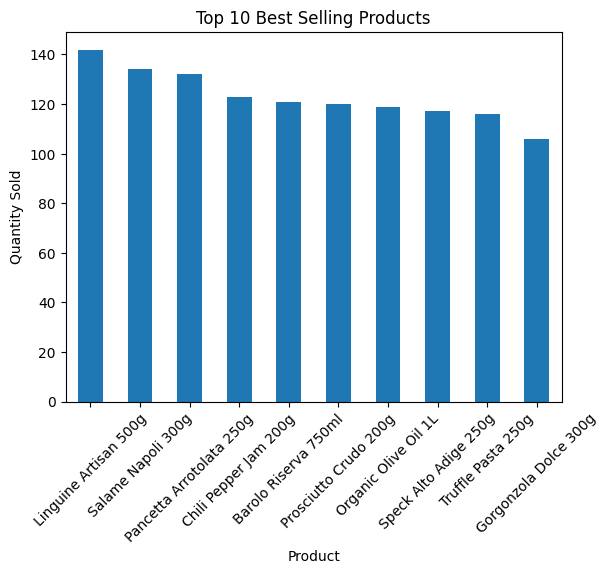

In [12]:
top_products.plot(kind="bar")

plt.title("Top 10 Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)

# Save chart
plt.savefig(
    "../visuals/top_selling_products.png",
    bbox_inches="tight"
)

plt.show()

### Insight

The analysis shows that some premium and frequently purchased products dominate total sales volume. Products with lower prices and daily consumption patterns tend to generate higher quantities sold.

## Most Profitable Categories

In [13]:
category_profit = (
    df.groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

category
Wine          5683.9
Cheese        1942.9
Olive Oil     1851.7
Cured Meat    1777.0
Pasta         1260.1
Preserves     1182.1
Bakery         786.2
Name: profit, dtype: float64

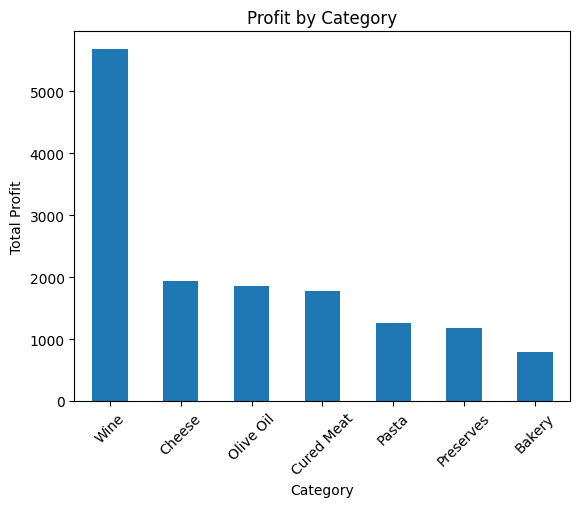

In [14]:
category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.savefig(
    "../visuals/profit_by_category.png",
    bbox_inches="tight"
)

plt.show()

### Insight

Wine and premium products generate higher profit margins compared to lower-cost bakery products. This suggests that premium inventory contributes significantly to business profitability.

## Monthly Sales Trend

In [15]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["month"] = df["order_date"].dt.month

monthly_sales = (
    df.groupby("month")["profit"]
    .sum()
)

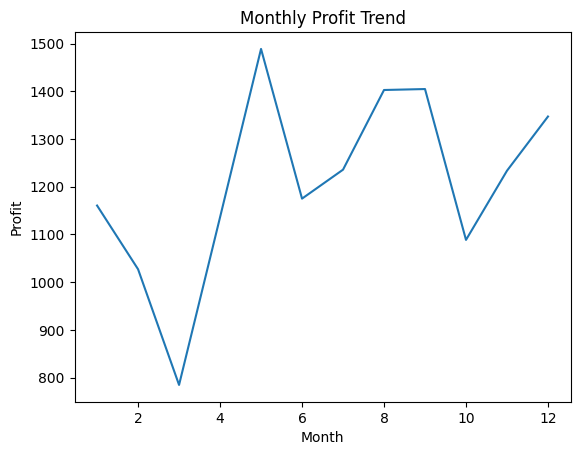

In [16]:
monthly_sales.plot(kind="line")

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.savefig(
    "../visuals/monthly_profit_trend.png",
    bbox_inches="tight"
)

plt.show()

## Low Stock Products

In [17]:
low_stock = df[df["stock_remaining"] < 10]

low_stock[["product_name", "stock_remaining"]].head(10)

,product_name,stock_remaining
0,Prosciutto Crudo 200g,4.0
5,Prosciutto Crudo 200g,9.0
51,Focaccia Genovese,6.0
60,Orecchiette 500g,8.0
83,Pancetta Arrotolata 250g,7.0
90,Pancetta Arrotolata 250g,7.0
116,Garlic Bread,0.0
120,Pitta Bread,6.0
129,Burrata 250g,7.0
152,Orange Marmalade 300g,1.0


### Insight

Some products frequently approach low inventory levels, suggesting potential stock management issues and possible future stock shortages.